# Dense Multi-Layer GCN v2 — 3-Fold CV + Kaggle Submission

> Legacy notebook: kept for experiment history. Canonical workflow is now
> `src/train_dense_gcn.py` for training/inference and `notebooks/dense_gcn_analysis.ipynb`
> for plots, tables, and report text.

Tuned from v1: reduced hidden_dim (256→128), increased dropout (0.3→0.5),
lower learning rate (1e-3→5e-4) to fix negative PCC from overfitting.
Evaluate on all 8 metrics and produce a submission CSV for Kaggle.

In [1]:
import sys
from pathlib import Path

notebook_dir = Path('.').resolve()
repo_root = notebook_dir.parent
sys.path.insert(0, str(repo_root))
sys.path.insert(0, str(repo_root / 'gcn-encoder-ca-decoder'))

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import KFold

from data_utils import vec_to_adj, to_tensor
from models.dense_gcn import DenseGCNGenerator
from utils.matrix_vectorizer import MatrixVectorizer
from utils.metrics import evaluate_fold
from utils.plotting import plot_folds

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
print(f'Device: {DEVICE}')

/home/jeet/y4/neurores-gnn/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda


## Load Data

In [2]:
def load_csv(path):
    arr = np.loadtxt(path, delimiter=',', skiprows=1, dtype=np.float32)
    return arr if arr.ndim > 1 else arr[None, :]

X_lr_train = load_csv(repo_root / 'data' / 'lr_train.csv')
Y_hr_train = load_csv(repo_root / 'data' / 'hr_train.csv')
X_lr_test  = load_csv(repo_root / 'data' / 'lr_test.csv')

print(f'Train LR: {X_lr_train.shape}')
print(f'Train HR: {Y_hr_train.shape}')
print(f'Test  LR: {X_lr_test.shape}')

Train LR: (167, 12720)
Train HR: (167, 35778)
Test  LR: (112, 12720)


## Config

In [3]:
N_LR, N_HR = 160, 268

MODEL_KWARGS = dict(n_lr=N_LR, n_hr=N_HR, hidden_dim=128, num_layers=3, dropout=0.5)
EPOCHS = 400
PATIENCE = 30
BATCH_SIZE = 16
LR = 5e-4
WEIGHT_DECAY = 1e-4

print(f'Dense GCN v2 config: {MODEL_KWARGS}')
print(f'Training:   {EPOCHS} epochs (patience={PATIENCE}), bs={BATCH_SIZE}, lr={LR}, wd={WEIGHT_DECAY}')

Dense GCN v2 config: {'n_lr': 160, 'n_hr': 268, 'hidden_dim': 128, 'num_layers': 3, 'dropout': 0.5}
Training:   400 epochs (patience=30), bs=16, lr=0.0005, wd=0.0001


## Training Loop (single fold)

In [4]:
def train_one_fold(X_tr, Y_tr, X_va, Y_va, fold_id):
    Xtr, Ytr = to_tensor(X_tr, DEVICE), to_tensor(Y_tr, DEVICE)
    Xva, Yva = to_tensor(X_va, DEVICE), to_tensor(Y_va, DEVICE)

    tr_loader = DataLoader(TensorDataset(Xtr, Ytr), batch_size=BATCH_SIZE, shuffle=True)
    va_loader = DataLoader(TensorDataset(Xva, Yva), batch_size=BATCH_SIZE, shuffle=False)

    model = DenseGCNGenerator(**MODEL_KWARGS).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    loss_fn = nn.MSELoss()

    best_val, best_state = float('inf'), None
    patience_counter = 0

    for epoch in range(1, EPOCHS + 1):
        model.train()
        for x_vec, y_vec in tr_loader:
            A = vec_to_adj(x_vec, N_LR)
            X = A  # full adjacency rows as 160-dim node features
            loss = loss_fn(model(A, X), y_vec)
            opt.zero_grad(set_to_none=True)
            loss.backward()
            opt.step()

        model.eval()
        val_losses = []
        with torch.no_grad():
            for x_vec, y_vec in va_loader:
                A = vec_to_adj(x_vec, N_LR)
                X = A
                val_losses.append(loss_fn(model(A, X), y_vec).item())

        val_loss = np.mean(val_losses)
        improved = val_loss < best_val
        if improved:
            best_val = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        if epoch % 10 == 0 or epoch == 1:
            mark = ' *' if improved else ''
            print(f'  Fold {fold_id} | Epoch {epoch:3d}/{EPOCHS} | Val: {val_loss:.6f}{mark}')

        if patience_counter >= PATIENCE:
            print(f'  Early stopping at epoch {epoch} (no improvement for {PATIENCE} epochs)')
            break

    model.load_state_dict(best_state)
    print(f'  Fold {fold_id} best val loss: {best_val:.6f}')
    return model

## 3-Fold Cross-Validation + Metrics

In [5]:
kf = KFold(n_splits=3, shuffle=True, random_state=SEED)
vectorizer = MatrixVectorizer()

fold_metrics = []
fold_models = []

for fold_id, (tr_idx, va_idx) in enumerate(kf.split(X_lr_train), start=1):
    print(f"\n{'='*50}")
    print(f'Fold {fold_id}: train={len(tr_idx)}, val={len(va_idx)}')
    print(f"{'='*50}")

    model = train_one_fold(
        X_lr_train[tr_idx], Y_hr_train[tr_idx],
        X_lr_train[va_idx], Y_hr_train[va_idx],
        fold_id,
    )
    fold_models.append(model)

    model.eval()
    va_preds, va_targets = [], []
    va_loader = DataLoader(
        TensorDataset(to_tensor(X_lr_train[va_idx], DEVICE),
                       to_tensor(Y_hr_train[va_idx], DEVICE)),
        batch_size=BATCH_SIZE, shuffle=False,
    )
    with torch.no_grad():
        for x_vec, y_vec in va_loader:
            A = vec_to_adj(x_vec, N_LR)
            X = A
            va_preds.append(model(A, X).cpu().numpy())
            va_targets.append(y_vec.cpu().numpy())

    pred_vecs = np.concatenate(va_preds)
    gt_vecs = np.concatenate(va_targets)
    pred_mats = np.stack([vectorizer.anti_vectorize(v, N_HR) for v in pred_vecs])
    gt_mats = np.stack([vectorizer.anti_vectorize(v, N_HR) for v in gt_vecs])

    print(f'\n  Metrics for fold {fold_id}:')
    metrics = evaluate_fold(pred_mats, gt_mats, verbose=True)
    fold_metrics.append(metrics)

print('\n\nAll 3 folds evaluated.')


Fold 1: train=111, val=56
  Fold 1 | Epoch   1/400 | Val: 6.221892 *
  Fold 1 | Epoch  10/400 | Val: 0.099089 *
  Fold 1 | Epoch  20/400 | Val: 0.096761
  Fold 1 | Epoch  30/400 | Val: 0.098230
  Fold 1 | Epoch  40/400 | Val: 0.099489
  Early stopping at epoch 46 (no improvement for 30 epochs)
  Fold 1 best val loss: 0.096517

  Metrics for fold 1:


Graph metrics: 100%|██████████| 56/56 [13:57<00:00, 14.95s/it]


Evaluation metrics:
  MAE             : 0.239558
  PCC             : -0.023726
  JSD             : 0.595233
  MAE (PC)        : 0.000861
  MAE (EC)        : 0.019246
  MAE (BC)        : 0.020801
  MAE (Strength)  : 52.618914
  MAE (Clustering): 0.220857

Fold 2: train=111, val=56
  Fold 2 | Epoch   1/400 | Val: 0.952387 *
  Fold 2 | Epoch  10/400 | Val: 0.110336 *
  Fold 2 | Epoch  20/400 | Val: 0.121251
  Fold 2 | Epoch  30/400 | Val: 0.121251
  Fold 2 | Epoch  40/400 | Val: 0.121251
  Early stopping at epoch 40 (no improvement for 30 epochs)
  Fold 2 best val loss: 0.110336

  Metrics for fold 2:


Graph metrics: 100%|██████████| 56/56 [11:03<00:00, 11.86s/it]


Evaluation metrics:
  MAE             : 0.252350
  PCC             : -0.022928
  JSD             : 0.624292
  MAE (PC)        : 0.000982
  MAE (EC)        : 0.021400
  MAE (BC)        : 0.021309
  MAE (Strength)  : 50.250196
  MAE (Clustering): 0.239591

Fold 3: train=112, val=55
  Fold 3 | Epoch   1/400 | Val: 0.788475 *
  Fold 3 | Epoch  10/400 | Val: 0.099891 *
  Fold 3 | Epoch  20/400 | Val: 0.100269
  Fold 3 | Epoch  30/400 | Val: 0.102150
  Fold 3 | Epoch  40/400 | Val: 0.103488
  Early stopping at epoch 43 (no improvement for 30 epochs)
  Fold 3 best val loss: 0.099088

  Metrics for fold 3:


Graph metrics: 100%|██████████| 55/55 [14:10<00:00, 15.47s/it]

Evaluation metrics:
  MAE             : 0.243054
  PCC             : -0.022668
  JSD             : 0.593882
  MAE (PC)        : 0.000833
  MAE (EC)        : 0.018372
  MAE (BC)        : 0.021036
  MAE (Strength)  : 51.762954
  MAE (Clustering): 0.225222


All 3 folds evaluated.


## Bar Plots

Plotting 3 fold(s).
Scale ratio (max/min over finite values): 52618914267387.039
Scale disparity detected — splitting into two figures:
  Matrix-level metrics: ['MAE', 'PCC', 'JSD']
  Graph-level metrics : ['MAE (PC)', 'MAE (EC)', 'MAE (BC)', 'MAE (Strength)', 'MAE (Clustering)']


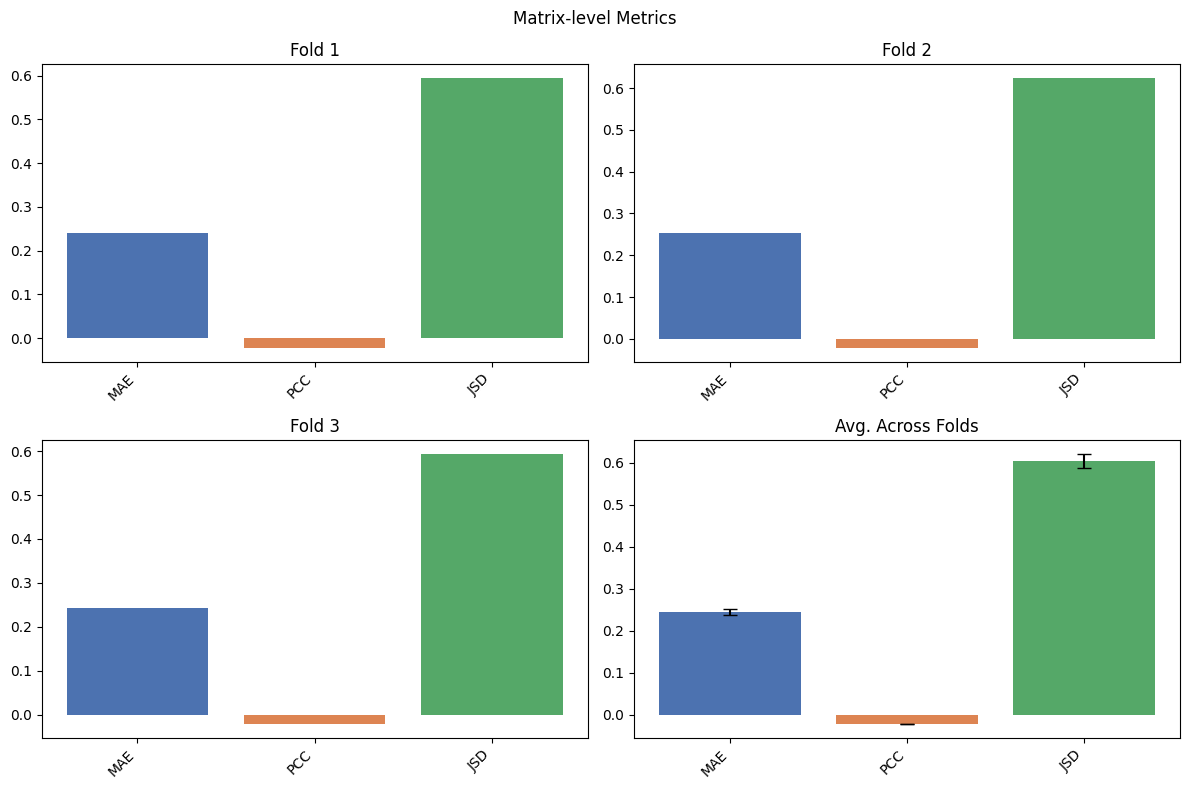

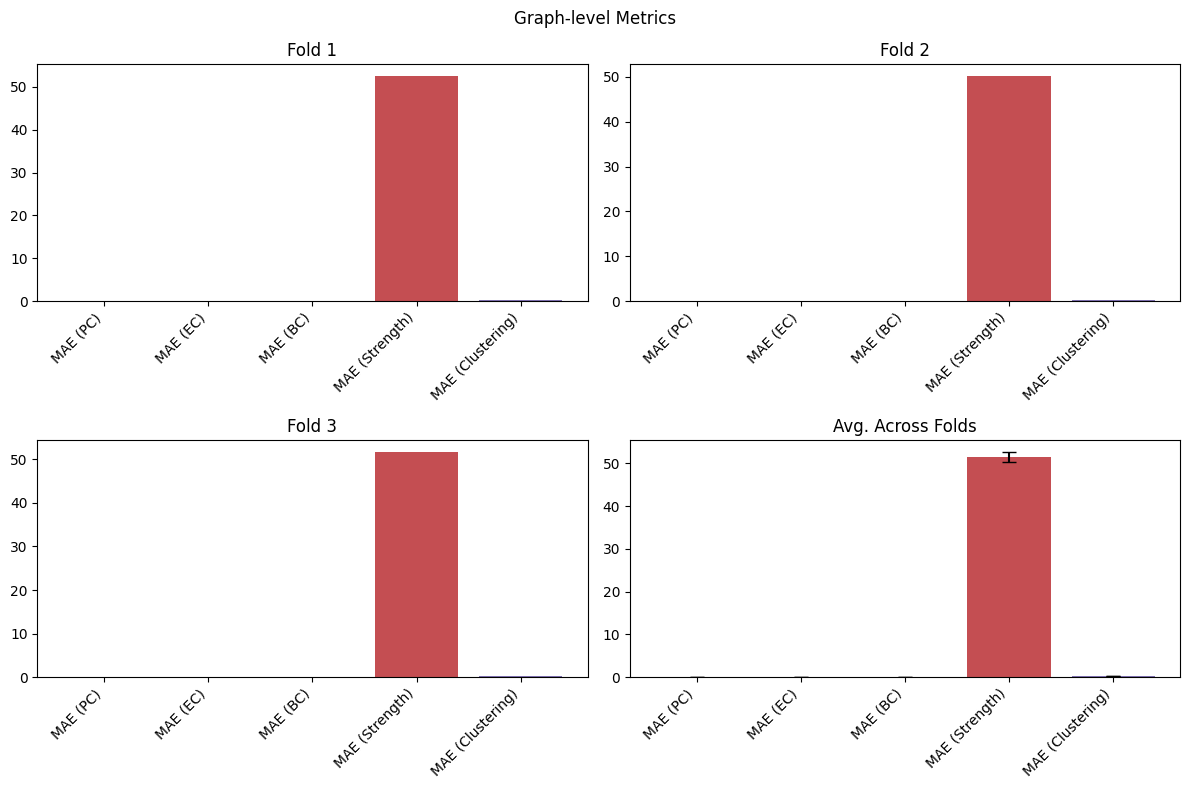

In [6]:
plot_folds(fold_metrics)

## Generate Kaggle Submission (ensemble of 3 folds)

In [7]:
test_preds = []
for i, model in enumerate(fold_models):
    model.eval()
    loader = DataLoader(
        TensorDataset(to_tensor(X_lr_test, DEVICE)),
        batch_size=BATCH_SIZE, shuffle=False,
    )
    preds = []
    with torch.no_grad():
        for (x_vec,) in loader:
            A = vec_to_adj(x_vec, N_LR)
            X = A
            preds.append(model(A, X).cpu().numpy())
    test_preds.append(np.concatenate(preds))
    print(f'Fold {i+1} test predictions: {test_preds[-1].shape}')

ensemble = np.clip(np.mean(test_preds, axis=0), a_min=0.0, a_max=None)
print(f'\nEnsemble shape: {ensemble.shape}')
print(f'Range: [{ensemble.min():.6f}, {ensemble.max():.6f}]')

Fold 1 test predictions: (112, 35778)
Fold 2 test predictions: (112, 35778)
Fold 3 test predictions: (112, 35778)

Ensemble shape: (112, 35778)
Range: [0.000000, 1.400746]


In [8]:
import pandas as pd

n_subjects, n_features = ensemble.shape
ids = np.arange(1, n_subjects * n_features + 1)
submission = pd.DataFrame({'ID': ids, 'Predicted': ensemble.flatten()})

sub_dir = repo_root / 'submission'
sub_dir.mkdir(exist_ok=True)

out_path = sub_dir / 'dense_gcn_v2_submission.csv'

submission.to_csv(out_path, index=False)

print(f'Saved to {out_path} ({len(submission):,} rows)')
print(submission.head())

Saved to /home/jeet/y4/neurores-gnn/submission/dense_gcn_v2_submission.csv (4,007,136 rows)
   ID  Predicted
0   1   0.000000
1   2   0.006905
2   3   0.036527
3   4   0.000000
4   5   0.081847


## Report-Ready Runtime + RAM Tracking (Point c)

Run the next two cells to obtain total 3-fold training wall-clock time and peak RAM usage for the report.

In [ ]:
import time
import pandas as pd

try:
    import psutil
except ImportError:
    psutil = None


def _process_ram_gb():
    """Return current process RSS in GB, if psutil is available."""
    if psutil is None:
        return np.nan
    return psutil.Process().memory_info().rss / (1024 ** 3)


def predict_vectors(model, X_np, batch_size=BATCH_SIZE):
    """Predict HR vectors from LR vectors in batches."""
    model.eval()
    preds = []
    with torch.no_grad():
        for s in range(0, len(X_np), batch_size):
            x_batch = to_tensor(X_np[s:s + batch_size], DEVICE)
            A = vec_to_adj(x_batch, N_LR)
            X = A
            preds.append(model(A, X).cpu().numpy())
    return np.concatenate(preds, axis=0)


def run_3fold_cv_with_tracking(X_lr, Y_hr, random_state=SEED):
    """
    3-fold CV that records:
      - fold metrics (all 8 measures)
      - total wall-clock runtime
      - peak process RAM during the CV run
    """
    kf = KFold(n_splits=3, shuffle=True, random_state=random_state)
    vec = MatrixVectorizer()

    fold_models_local = []
    fold_metrics_local = []
    fold_timing = []

    cv_start = time.perf_counter()
    peak_ram_gb = _process_ram_gb()

    for fold_idx, (tr_idx, va_idx) in enumerate(kf.split(X_lr), start=1):
        print('\n' + '=' * 50)
        print(f'Fold {fold_idx}: train={len(tr_idx)}, val={len(va_idx)}')
        print('=' * 50)

        fold_start = time.perf_counter()
        model = train_one_fold(
            X_lr[tr_idx], Y_hr[tr_idx],
            X_lr[va_idx], Y_hr[va_idx],
            fold_id=fold_idx,
        )
        fold_seconds = time.perf_counter() - fold_start

        print(f'\n  Metrics for fold {fold_idx}:')
        pred_vecs = predict_vectors(model, X_lr[va_idx])
        gt_vecs = Y_hr[va_idx]

        pred_mats = np.stack([vec.anti_vectorize(v, N_HR) for v in pred_vecs])
        gt_mats = np.stack([vec.anti_vectorize(v, N_HR) for v in gt_vecs])

        metrics = evaluate_fold(pred_mats, gt_mats, verbose=True)
        fold_models_local.append(model)
        fold_metrics_local.append(metrics)
        fold_timing.append(fold_seconds)

        current_ram = _process_ram_gb()
        if np.isfinite(current_ram):
            peak_ram_gb = np.nanmax([peak_ram_gb, current_ram])

    total_seconds = time.perf_counter() - cv_start

    print('\n' + '=' * 50)
    print('3-Fold CV Resource Summary')
    print('=' * 50)
    print(f'Total CV time: {total_seconds:.1f} s ({total_seconds / 60:.2f} min)')
    if np.isfinite(peak_ram_gb):
        print(f'Peak RAM (RSS): {peak_ram_gb:.3f} GB')
    else:
        print('Peak RAM (RSS): N/A (install psutil for RAM tracking)')

    return {
        'fold_models': fold_models_local,
        'fold_metrics': fold_metrics_local,
        'fold_seconds': fold_timing,
        'total_seconds': total_seconds,
        'peak_ram_gb': peak_ram_gb,
    }

In [ ]:
# Execute this tracked CV run for report numbers.
# It also refreshes fold_models/fold_metrics for downstream plotting/submission cells.
cv_run = run_3fold_cv_with_tracking(X_lr_train, Y_hr_train)

fold_models = cv_run['fold_models']
fold_metrics = cv_run['fold_metrics']

# Convenience fields for report section II-A(c)
cv_total_time_sec = cv_run['total_seconds']
cv_peak_ram_gb = cv_run['peak_ram_gb']

In [ ]:
# Compact table for report point II-A(b) and II-A(c)
metric_names = [
    'MAE', 'PCC', 'JSD',
    'MAE (PC)', 'MAE (EC)', 'MAE (BC)',
    'MAE (Strength)', 'MAE (Clustering)'
]

rows = []
for i, m in enumerate(fold_metrics, start=1):
    row = {'Fold': f'Fold {i}'}
    row.update({k: m[k] for k in metric_names})
    rows.append(row)

metrics_df = pd.DataFrame(rows)
mean_row = {'Fold': 'Mean'}
std_row = {'Fold': 'Std'}
for k in metric_names:
    vals = metrics_df[k].values.astype(float)
    mean_row[k] = np.nanmean(vals)
    std_row[k] = np.nanstd(vals, ddof=1) if len(vals) > 1 else 0.0

report_metrics_df = pd.concat([metrics_df, pd.DataFrame([mean_row, std_row])], ignore_index=True)
display(report_metrics_df)

resource_df = pd.DataFrame([
    {
        'Total CV time (sec)': cv_total_time_sec,
        'Total CV time (min)': cv_total_time_sec / 60.0,
        'Peak RAM (GB)': cv_peak_ram_gb,
        'Device': DEVICE,
    }
])
display(resource_df)

## Full Retraining on train_LR/train_HR then test_LR Prediction (Point d)

This section follows Kaggle protocol explicitly:
1) retrain one final model on all 167 training subjects,
2) predict test_HR from test_LR,
3) save a dedicated full-retrain submission CSV.

In [ ]:
def train_full_model(X_tr, Y_tr, epochs=EPOCHS):
    """Train final model on full training set (no validation split)."""
    Xtr, Ytr = to_tensor(X_tr, DEVICE), to_tensor(Y_tr, DEVICE)
    tr_loader = DataLoader(TensorDataset(Xtr, Ytr), batch_size=BATCH_SIZE, shuffle=True)

    model = DenseGCNGenerator(**MODEL_KWARGS).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    loss_fn = nn.MSELoss()

    for epoch in range(1, epochs + 1):
        model.train()
        train_losses = []
        for x_vec, y_vec in tr_loader:
            A = vec_to_adj(x_vec, N_LR)
            X = A
            loss = loss_fn(model(A, X), y_vec)
            opt.zero_grad(set_to_none=True)
            loss.backward()
            opt.step()
            train_losses.append(loss.item())

        if epoch % 10 == 0 or epoch == 1 or epoch == epochs:
            print(f'  Full-train | Epoch {epoch:3d}/{epochs} | Train loss: {np.mean(train_losses):.6f}')

    return model


# Train on all 167 paired samples
full_train_start = time.perf_counter()
full_model = train_full_model(X_lr_train, Y_hr_train, epochs=EPOCHS)
full_train_seconds = time.perf_counter() - full_train_start
print(f'\nFull retraining time: {full_train_seconds:.1f} s ({full_train_seconds/60:.2f} min)')

# Predict test_HR from test_LR
test_pred = predict_vectors(full_model, X_lr_test)
test_pred = np.maximum(test_pred, 0.0)  # safety clamp for competition format

# Save dedicated full-retrain submission
ids = np.arange(test_pred.size)
submission_full = pd.DataFrame({'ID': ids, 'Predicted': test_pred.flatten()})
sub_dir = repo_root / 'submission'
sub_dir.mkdir(exist_ok=True)
out_full = sub_dir / 'dense_gcn_v2_full_retrain_submission.csv'
submission_full.to_csv(out_full, index=False)

print(f'Saved to {out_full} ({len(submission_full):,} rows)')
display(submission_full.head())

In [ ]:
# Fill these after uploading the full-retrain submission to Kaggle.
KAGGLE_PUBLIC_SCORE = None
KAGGLE_RANK = None
KAGGLE_TOTAL_TEAMS = None

kaggle_report_df = pd.DataFrame([
    {
        'Submission file': 'dense_gcn_v2_full_retrain_submission.csv',
        'Public score': KAGGLE_PUBLIC_SCORE,
        'Rank': KAGGLE_RANK,
        'Total teams': KAGGLE_TOTAL_TEAMS,
    }
])
display(kaggle_report_df)